# 🏋️ Milestone 2 — Feature Extraction and Modeling
### Real Fitbit Dataset | TSFresh + Prophet + Clustering

In [1]:
!pip install tsfresh prophet scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

from prophet import Prophet

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 📂 Step 1 · Load All Files

In [3]:
daily    = pd.read_csv("dailyActivity_merged.csv")
hourly_s = pd.read_csv("hourlySteps_merged.csv")
hourly_i = pd.read_csv("hourlyIntensities_merged.csv")
sleep    = pd.read_csv("minuteSleep_merged.csv")
hr       = pd.read_csv("heartrate_seconds_merged.csv")

print("✅ All files loaded")
print(f"dailyActivity     : {daily.shape}")
print(f"hourlySteps       : {hourly_s.shape}")
print(f"hourlyIntensities : {hourly_i.shape}")
print(f"minuteSleep       : {sleep.shape}")
print(f"heartrate         : {hr.shape}")

✅ All files loaded
dailyActivity     : (457, 15)
hourlySteps       : (24084, 3)
hourlyIntensities : (24084, 4)
minuteSleep       : (198559, 4)
heartrate         : (1154681, 3)


## 👁 Step 2 · Preview Each File

In [4]:
print("=== dailyActivity ===")
print(daily.columns.tolist())
display(daily.head(3))

print("\n=== hourlySteps ===")
display(hourly_s.head(3))

print("\n=== hourlyIntensities ===")
display(hourly_i.head(3))

print("\n=== minuteSleep ===")
display(sleep.head(3))

print("\n=== heartrate ===")
display(hr.head(3))

=== dailyActivity ===
['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944



=== hourlySteps ===


,Id,ActivityHour,StepTotal
0,1503960366,3/12/2016 12:00:00 AM,0
1,1503960366,3/12/2016 1:00:00 AM,0
2,1503960366,3/12/2016 2:00:00 AM,0



=== hourlyIntensities ===


,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1503960366,3/12/2016 12:00:00 AM,0,0.0
1,1503960366,3/12/2016 1:00:00 AM,0,0.0
2,1503960366,3/12/2016 2:00:00 AM,0,0.0



=== minuteSleep ===


,Id,date,value,logId
0,1503960366,3/13/2016 2:39:30 AM,1,11114919637
1,1503960366,3/13/2016 2:40:30 AM,1,11114919637
2,1503960366,3/13/2016 2:41:30 AM,1,11114919637



=== heartrate ===


,Id,Time,Value
0,2022484408,4/1/2016 7:54:00 AM,93
1,2022484408,4/1/2016 7:54:05 AM,91
2,2022484408,4/1/2016 7:54:10 AM,96


## ⏱ Step 3 · Parse All Timestamps

In [5]:
# dailyActivity
daily["ActivityDate"] = pd.to_datetime(
    daily["ActivityDate"], format="%m/%d/%Y"
)

# hourlySteps
hourly_s["ActivityHour"] = pd.to_datetime(
    hourly_s["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p"
)

# hourlyIntensities
hourly_i["ActivityHour"] = pd.to_datetime(
    hourly_i["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p"
)

# minuteSleep
sleep["date"] = pd.to_datetime(
    sleep["date"], format="%m/%d/%Y %I:%M:%S %p"
)

# heartrate
hr["Time"] = pd.to_datetime(
    hr["Time"], format="%m/%d/%Y %I:%M:%S %p"
)

print("✅ All timestamps parsed successfully")
print("\ndailyActivity date range:")
print("  Start:", daily["ActivityDate"].min())
print("  End  :", daily["ActivityDate"].max())
print("\nHeartrate time range:")
print("  Start:", hr["Time"].min())
print("  End  :", hr["Time"].max())

✅ All timestamps parsed successfully

dailyActivity date range:
  Start: 2016-03-12 00:00:00
  End  : 2016-04-12 00:00:00

Heartrate time range:
  Start: 2016-03-29 00:00:05
  End  : 2016-04-12 11:03:15


## 🔍 Step 4 · Check Null Values (Milestone 1 Output)

In [6]:
print("=" * 55)
print("NULL VALUE CHECK — ALL FILES")
print("=" * 55)

for name, df in [
    ("dailyActivity",     daily),
    ("hourlySteps",       hourly_s),
    ("hourlyIntensities", hourly_i),
    ("minuteSleep",       sleep),
    ("heartrate",         hr)
]:
    nulls = df.isnull().sum().sum()
    print(f"\n{name}:")
    print(f"  Total nulls : {nulls}")
    print(f"  Shape       : {df.shape}")
    if nulls > 0:
        print(f"  Null cols   : {df.isnull().sum()[df.isnull().sum()>0].to_dict()}")
    else:
        print(f"  Status      : ✅ Perfectly clean")

NULL VALUE CHECK — ALL FILES

dailyActivity:
  Total nulls : 0
  Shape       : (457, 15)
  Status      : ✅ Perfectly clean

hourlySteps:
  Total nulls : 0
  Shape       : (24084, 3)
  Status      : ✅ Perfectly clean

hourlyIntensities:
  Total nulls : 0
  Shape       : (24084, 4)
  Status      : ✅ Perfectly clean

minuteSleep:
  Total nulls : 0
  Shape       : (198559, 4)
  Status      : ✅ Perfectly clean

heartrate:
  Total nulls : 0
  Shape       : (1154681, 3)
  Status      : ✅ Perfectly clean


## 📊 Step 5 · Dataset Overview and Stats

In [7]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)

print(f"\nUnique Users — dailyActivity : {daily['Id'].nunique()}")
print(f"Unique Users — heartrate     : {hr['Id'].nunique()}")
print(f"Unique Users — sleep         : {sleep['Id'].nunique()}")

print("\n--- Steps Summary ---")
print(daily["TotalSteps"].describe().round(2))

print("\n--- Calories Summary ---")
print(daily["Calories"].describe().round(2))

print("\n--- Heart Rate Summary ---")
print(hr["Value"].describe().round(2))

print("\n--- Sleep Stage Values ---")
print("1 = Light Sleep | 2 = Deep Sleep | 3 = REM")
print(sleep["value"].value_counts())

DATASET OVERVIEW

Unique Users — dailyActivity : 35
Unique Users — heartrate     : 14
Unique Users — sleep         : 23

--- Steps Summary ---
count      457.00
mean      6546.56
std       5398.49
min          0.00
25%       1988.00
50%       5986.00
75%      10198.00
max      28497.00
Name: TotalSteps, dtype: float64

--- Calories Summary ---
count     457.00
mean     2189.45
std       815.48
min         0.00
25%      1776.00
50%      2062.00
75%      2667.00
max      4562.00
Name: Calories, dtype: float64

--- Heart Rate Summary ---
count    1154681.00
mean          79.76
std           18.73
min           36.00
25%           66.00
50%           77.00
75%           90.00
max          185.00
Name: Value, dtype: float64

--- Sleep Stage Values ---
1 = Light Sleep | 2 = Deep Sleep | 3 = REM
value
1    183526
2     13010
3      2023
Name: count, dtype: int64


## 🕐 Step 6 · Resample Heartrate to 1-Minute Granularity (Time Normalization)

In [8]:
hr_minute = (
    hr.set_index("Time")
    .groupby("Id")["Value"]
    .resample("1min")
    .mean()
    .reset_index()
)

hr_minute.columns = ["Id", "Time", "HeartRate"]
hr_minute = hr_minute.dropna()

print("✅ Heart rate resampled to 1-minute granularity")
print(f"Before resampling (seconds) : {hr.shape[0]:,} rows")
print(f"After resampling  (minutes) : {hr_minute.shape[0]:,} rows")
print(f"\nSample:")
display(hr_minute.head(10))

✅ Heart rate resampled to 1-minute granularity
Before resampling (seconds) : 1,154,681 rows
After resampling  (minutes) : 140,987 rows

Sample:


,Id,Time,HeartRate
0,2022484408,2016-04-01 07:54:00,99.600000
1,2022484408,2016-04-01 07:55:00,110.111111
2,2022484408,2016-04-01 07:56:00,92.555556
3,2022484408,2016-04-01 07:57:00,90.400000
4,2022484408,2016-04-01 07:58:00,97.875000
5,2022484408,2016-04-01 07:59:00,107.625000
6,2022484408,2016-04-01 08:00:00,106.333333
7,2022484408,2016-04-01 08:01:00,106.666667
8,2022484408,2016-04-01 08:02:00,104.375000
9,2022484408,2016-04-01 08:03:00,83.777778


## 📋 Step 7 · Time Normalization Log (Milestone 1 Output)

In [9]:
print("=" * 55)
print("TIME NORMALIZATION LOG")
print("=" * 55)

print(f"\n✅ Heartrate resampled: seconds → 1-minute intervals")
print(f"   Rows before : {hr.shape[0]:,}")
print(f"   Rows after  : {hr_minute.shape[0]:,}")

print(f"\n✅ Date range (dailyActivity):")
print(f"   Start : {daily['ActivityDate'].min().date()}")
print(f"   End   : {daily['ActivityDate'].max().date()}")
print(f"   Span  : {(daily['ActivityDate'].max() - daily['ActivityDate'].min()).days} days")

freq_check = (
    hourly_s.groupby("Id")["ActivityHour"]
    .diff().dropna().dt.total_seconds() / 3600
)
print(f"\n✅ Hourly data frequency confirmed: 1-hour intervals")
print(f"   Median interval : {freq_check.median():.1f} hours")
print(f"   All 1-hour?     : {(freq_check == 1.0).mean()*100:.1f}% of records")

print(f"\n✅ Sleep data at 1-minute granularity")
print(f"   Sleep stages    : 1=Light, 2=Deep, 3=REM")
print(f"   Total records   : {sleep.shape[0]:,}")

print(f"\n⚠️  Timezone: All timestamps stored as local time")
print(f"   UTC normalization: Not applicable (no timezone info in source)")
print("=" * 55)

TIME NORMALIZATION LOG

✅ Heartrate resampled: seconds → 1-minute intervals
   Rows before : 1,154,681
   Rows after  : 140,987

✅ Date range (dailyActivity):
   Start : 2016-03-12
   End   : 2016-04-12
   Span  : 31 days

✅ Hourly data frequency confirmed: 1-hour intervals
   Median interval : 1.0 hours
   All 1-hour?     : 100.0% of records

✅ Sleep data at 1-minute granularity
   Sleep stages    : 1=Light, 2=Deep, 3=REM
   Total records   : 198,559

⚠️  Timezone: All timestamps stored as local time
   UTC normalization: Not applicable (no timezone info in source)


## 🔗 Step 8 · Aggregate and Build Master DataFrame

In [10]:
# Heart rate daily aggregation
hr_minute["Date"] = hr_minute["Time"].dt.date
hr_daily = (
    hr_minute.groupby(["Id", "Date"])["HeartRate"]
    .agg(["mean", "max", "min", "std"])
    .reset_index()
    .rename(columns={
        "mean": "AvgHR",
        "max":  "MaxHR",
        "min":  "MinHR",
        "std":  "StdHR"
    })
)

# Sleep daily aggregation
sleep["Date"] = sleep["date"].dt.date
sleep_daily = (
    sleep.groupby(["Id", "Date"])
    .agg(
        TotalSleepMinutes=("value", "count"),
        DominantSleepStage=("value", lambda x: x.mode()[0])
    )
    .reset_index()
)

# Merge into master
master = daily.copy()
master = master.rename(columns={"ActivityDate": "Date"})
master["Date"] = master["Date"].dt.date

master = master.merge(hr_daily,    on=["Id", "Date"], how="left")
master = master.merge(sleep_daily, on=["Id", "Date"], how="left")

# Fill nulls
master["TotalSleepMinutes"]  = master["TotalSleepMinutes"].fillna(0)
master["DominantSleepStage"] = master["DominantSleepStage"].fillna(0)

for col in ["AvgHR", "MaxHR", "MinHR", "StdHR"]:
    master[col] = master.groupby("Id")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("✅ Master dataframe created")
print(f"Shape : {master.shape}")
print(f"Users : {master['Id'].nunique()}")
print(f"Nulls : {master.isnull().sum().sum()}")
display(master.head())

✅ Master dataframe created
Shape : (457, 21)
Users : 35
Nulls : 1092


,Id,Date,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,AvgHR,MaxHR,MinHR,StdHR,TotalSleepMinutes,DominantSleepStage
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,...,12,205,804,1819,NaN,NaN,NaN,NaN,386.0,1.0
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,...,17,274,588,2154,NaN,NaN,NaN,NaN,472.0,1.0
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,...,5,268,605,1944,NaN,NaN,NaN,NaN,506.0,1.0
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,...,20,224,1080,1932,NaN,NaN,NaN,NaN,77.0,1.0
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,...,28,243,763,1886,NaN,NaN,NaN,NaN,378.0,1.0


## 👁 Step 9 · Cleaned Dataset Preview (Milestone 1 Output)

In [11]:
print("=" * 55)
print("CLEANED DATASET PREVIEW")
print("=" * 55)
print(f"\nShape  : {master.shape}")
print(f"Users  : {master['Id'].nunique()}")
print(f"Nulls  : {master.isnull().sum().sum()}")

print("\nKey columns summary:")
key_cols = ["TotalSteps", "Calories", "AvgHR",
            "TotalSleepMinutes", "VeryActiveMinutes", "SedentaryMinutes"]
print(master[key_cols].describe().round(2))

display(master[["Id", "Date", "TotalSteps", "Calories",
                "AvgHR", "TotalSleepMinutes",
                "VeryActiveMinutes", "SedentaryMinutes"]].head(20))

CLEANED DATASET PREVIEW

Shape  : (457, 21)
Users  : 35
Nulls  : 1092

Key columns summary:
       TotalSteps  Calories   AvgHR  TotalSleepMinutes  VeryActiveMinutes  \
count      457.00    457.00  184.00             457.00             457.00   
mean      6546.56   2189.45   77.26             187.28              16.62   
std       5398.49    815.48    9.33             235.54              28.92   
min          0.00      0.00   55.74               0.00               0.00   
25%       1988.00   1776.00   71.28               0.00               0.00   
50%       5986.00   2062.00   78.18               0.00               0.00   
75%      10198.00   2667.00   82.54             428.00              25.00   
max      28497.00   4562.00  107.58             959.00             202.00   

       SedentaryMinutes  
count            457.00  
mean             995.28  
std              337.02  
min               32.00  
25%              728.00  
50%             1057.00  
75%             1285.00  
max   

,Id,Date,TotalSteps,Calories,AvgHR,TotalSleepMinutes,VeryActiveMinutes,SedentaryMinutes
0,1503960366,2016-03-25,11004,1819,NaN,386.0,33,804
1,1503960366,2016-03-26,17609,2154,NaN,472.0,89,588
2,1503960366,2016-03-27,12736,1944,NaN,506.0,56,605
3,1503960366,2016-03-28,13231,1932,NaN,77.0,39,1080
4,1503960366,2016-03-29,12041,1886,NaN,378.0,28,763
5,1503960366,2016-03-30,10970,1820,NaN,0.0,30,1174
6,1503960366,2016-03-31,12256,1889,NaN,336.0,33,820
7,1503960366,2016-04-01,12262,1868,NaN,306.0,47,866
8,1503960366,2016-04-02,11248,1843,NaN,509.0,40,636
9,1503960366,2016-04-03,10016,1850,NaN,426.0,15,655


---
## 🧪 Milestone 2 · TSFresh Feature Extraction

### Step 10 · Prepare TSFresh Input

In [12]:
ts_hr = hr_minute[["Id", "Time", "HeartRate"]].copy()
ts_hr = ts_hr.dropna()
ts_hr = ts_hr.sort_values(["Id", "Time"])
ts_hr = ts_hr.rename(columns={
    "Id":        "id",
    "Time":      "time",
    "HeartRate": "value"
})

print("✅ TSFresh input prepared from real minute-level heart rate")
print(f"Shape      : {ts_hr.shape}")
print(f"Users      : {ts_hr['id'].nunique()}")
print(f"Date range : {ts_hr['time'].min()} → {ts_hr['time'].max()}")
print(f"\nSample:")
display(ts_hr.head(10))

✅ TSFresh input prepared from real minute-level heart rate
Shape      : (140987, 3)
Users      : 14
Date range : 2016-03-29 00:00:00 → 2016-04-12 11:03:00

Sample:


,id,time,value
0,2022484408,2016-04-01 07:54:00,99.600000
1,2022484408,2016-04-01 07:55:00,110.111111
2,2022484408,2016-04-01 07:56:00,92.555556
3,2022484408,2016-04-01 07:57:00,90.400000
4,2022484408,2016-04-01 07:58:00,97.875000
5,2022484408,2016-04-01 07:59:00,107.625000
6,2022484408,2016-04-01 08:00:00,106.333333
7,2022484408,2016-04-01 08:01:00,106.666667
8,2022484408,2016-04-01 08:02:00,104.375000
9,2022484408,2016-04-01 08:03:00,83.777778


### Step 11 · Run TSFresh

In [13]:
print("⏳ Extracting TSFresh features from real heart rate data...")
print("   Using MinimalFCParameters for speed...")

features = extract_features(
    ts_hr,
    column_id="id",
    column_sort="time",
    column_value="value",
    default_fc_parameters=MinimalFCParameters(),
    disable_progressbar=False
)

features = features.dropna(axis=1, how="all")

print(f"\n✅ TSFresh extraction complete!")
print(f"Users (rows)    : {features.shape[0]}")
print(f"Features (cols) : {features.shape[1]}")
print(f"\nFeature names extracted:")
for i, col in enumerate(features.columns):
    print(f"  {i+1}. {col}")

⏳ Extracting TSFresh features from real heart rate data...
   Using MinimalFCParameters for speed...


Feature Extraction: 100%|██████████| 14/14 [00:03<00:00,  4.27it/s]


✅ TSFresh extraction complete!
Users (rows)    : 14
Features (cols) : 10

Feature names extracted:
  1. value__sum_values
  2. value__median
  3. value__mean
  4. value__length
  5. value__standard_deviation
  6. value__variance
  7. value__root_mean_square
  8. value__maximum
  9. value__absolute_maximum
  10. value__minimum


### Step 12 · TSFresh Feature Matrix Heatmap (Screenshot This)

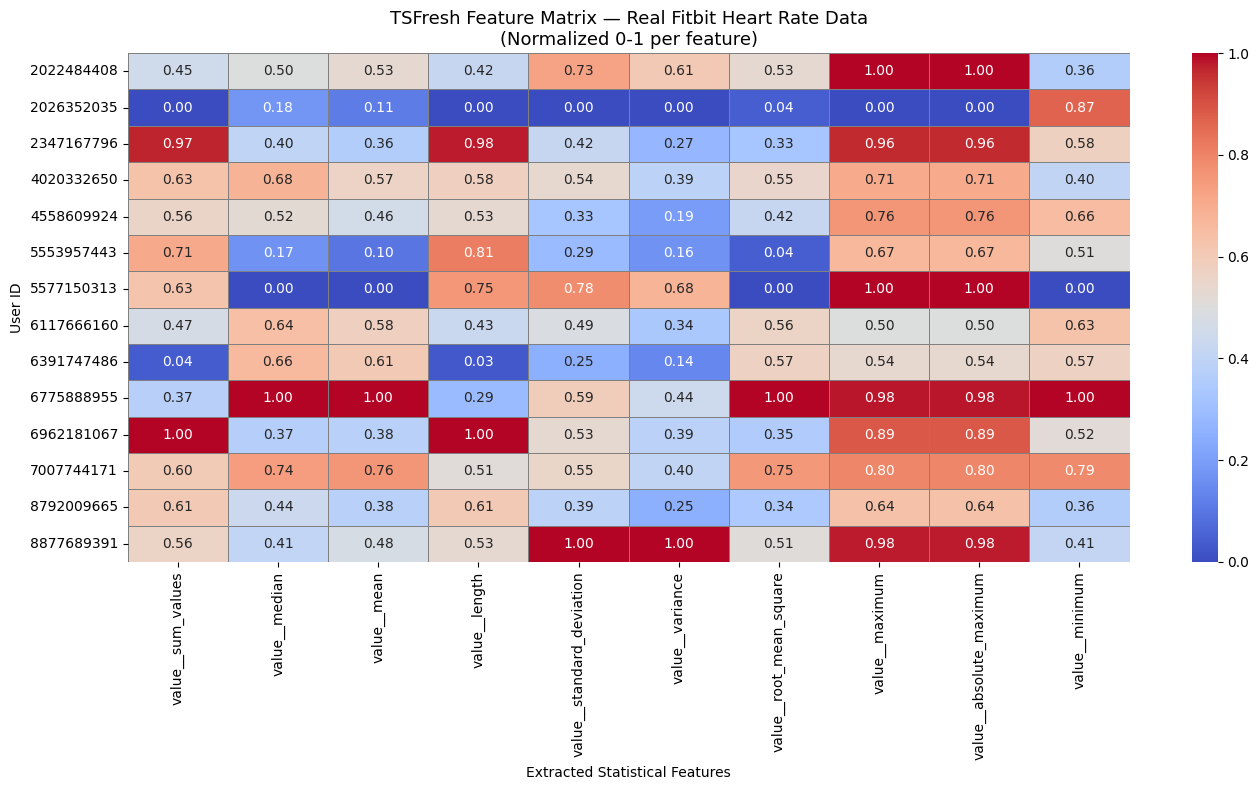

✅ TSFresh feature matrix — SCREENSHOT THIS
✅ Features saved to tsfresh_features.csv


In [14]:
scaler_vis   = MinMaxScaler()
features_norm = pd.DataFrame(
    scaler_vis.fit_transform(features),
    index=features.index,
    columns=features.columns
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    features_norm,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="gray"
)
plt.title("TSFresh Feature Matrix — Real Fitbit Heart Rate Data\n(Normalized 0-1 per feature)", fontsize=13)
plt.xlabel("Extracted Statistical Features")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

features.to_csv("tsfresh_features.csv")
print("✅ TSFresh feature matrix — SCREENSHOT THIS")
print("✅ Features saved to tsfresh_features.csv")

---
## 📈 Milestone 2 · Prophet Trend Forecasting

### Step 13 · Prepare Prophet — Heart Rate

In [15]:
prophet_hr = (
    hr_minute.groupby("Date")["HeartRate"]
    .mean()
    .reset_index()
)
prophet_hr.columns = ["ds", "y"]
prophet_hr["ds"]   = pd.to_datetime(prophet_hr["ds"])
prophet_hr         = prophet_hr.dropna().sort_values("ds")

print("✅ Prophet HR input ready")
print(f"Shape    : {prophet_hr.shape}")
print(f"HR range : {prophet_hr['y'].min():.1f} → {prophet_hr['y'].max():.1f} bpm")
display(prophet_hr.head(10))

✅ Prophet HR input ready
Shape    : (15, 2)
HR range : 69.5 → 78.3 bpm


,ds,y
0,2016-03-29,69.691878
1,2016-03-30,71.769647
2,2016-03-31,71.235454
3,2016-04-01,75.744390
4,2016-04-02,75.177863
5,2016-04-03,74.681626
6,2016-04-04,74.520963
7,2016-04-05,76.530066
8,2016-04-06,78.156630
9,2016-04-07,78.339381


### Step 14 · Fit Prophet on Heart Rate

In [16]:
print("⏳ Fitting Prophet on real heart rate data...")

model_hr = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    interval_width=0.80,
    changepoint_prior_scale=0.01,  # much lower — less aggressive trend change
    changepoint_range=0.8           # only detect changepoints in first 80% of data
)

model_hr.fit(prophet_hr)
future_hr   = model_hr.make_future_dataframe(periods=30)
forecast_hr = model_hr.predict(future_hr)

print("✅ Prophet fitted on real heart rate")
print(f"Forecast shape: {forecast_hr.shape}")
display(forecast_hr[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10))

⏳ Fitting Prophet on real heart rate data...


19:10:38 - cmdstanpy - INFO - Chain [1] start processing
19:10:39 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet fitted on real heart rate
Forecast shape: (45, 16)


,ds,yhat,yhat_lower,yhat_upper
35,2016-05-03,79.987432,77.315305,82.803087
36,2016-05-04,84.035970,81.423388,86.644273
37,2016-05-05,83.860191,81.134292,86.635192
38,2016-05-06,86.011095,83.600685,88.569565
39,2016-05-07,85.524041,82.992661,88.112907
40,2016-05-08,84.668919,81.878201,87.145838
41,2016-05-09,83.690304,81.145803,86.356151
42,2016-05-10,82.004641,79.435733,84.535012
43,2016-05-11,86.053179,83.339340,88.950143
44,2016-05-12,85.877400,83.204697,88.410256


### Step 15 · Prophet Heart Rate Forecast Plot (Screenshot This)

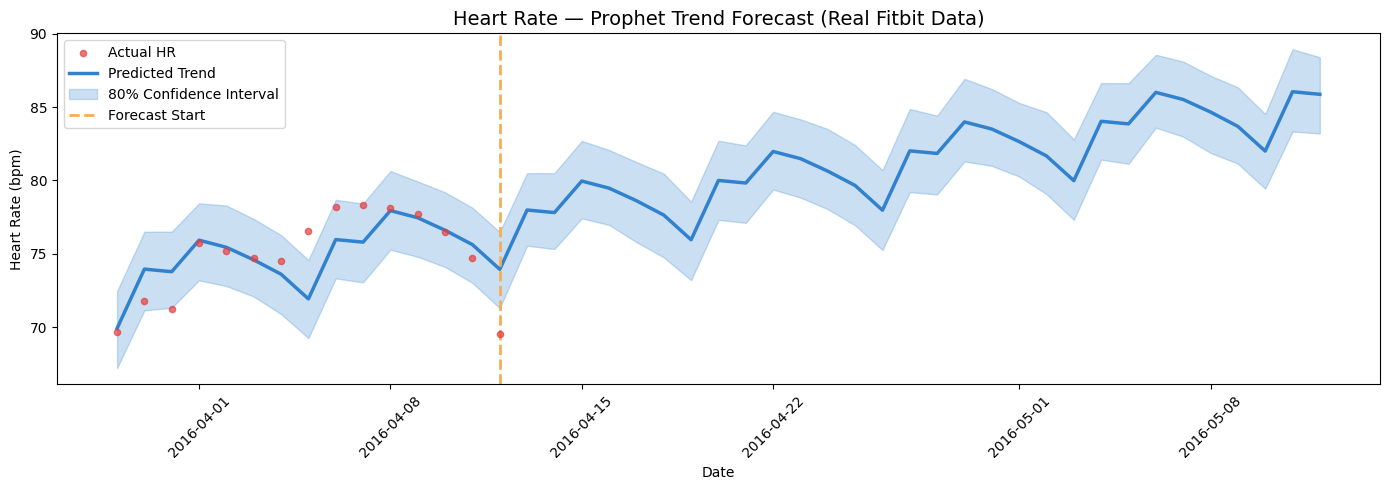

✅ Prophet HR forecast — SCREENSHOT THIS


In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(prophet_hr["ds"], prophet_hr["y"],
           color="#e53e3e", s=20, alpha=0.7,
           label="Actual HR", zorder=3)

ax.plot(forecast_hr["ds"], forecast_hr["yhat"],
        color="#3182ce", linewidth=2.5,
        label="Predicted Trend")

ax.fill_between(
    forecast_hr["ds"],
    forecast_hr["yhat_lower"],
    forecast_hr["yhat_upper"],
    alpha=0.25, color="#3182ce",
    label="80% Confidence Interval"
)

forecast_start = prophet_hr["ds"].max()
ax.axvline(forecast_start, color="#f6ad55",
           linestyle="--", linewidth=2,
           label="Forecast Start")

ax.set_title("Heart Rate — Prophet Trend Forecast (Real Fitbit Data)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Heart Rate (bpm)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Prophet HR forecast — SCREENSHOT THIS")

### Step 16 · Prophet Components

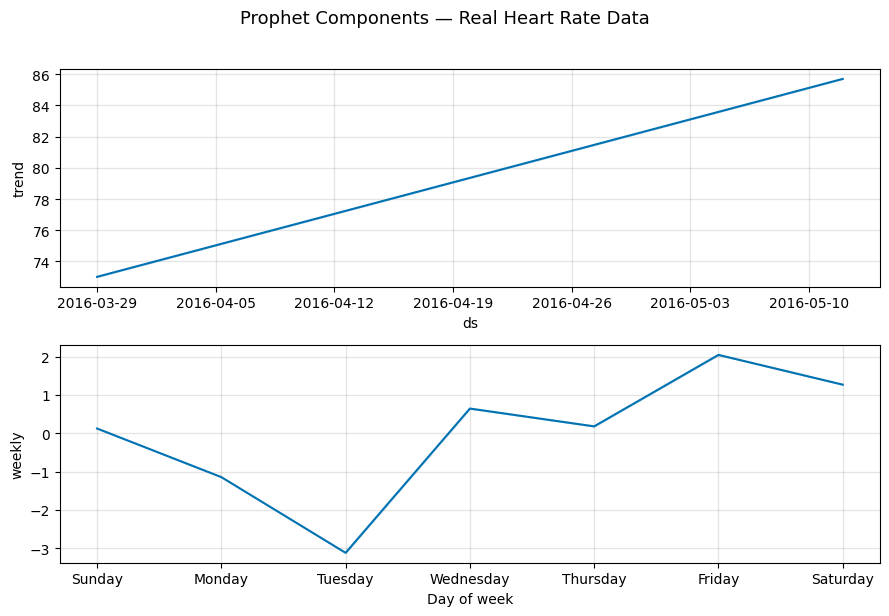

In [18]:
fig2 = model_hr.plot_components(forecast_hr)
plt.suptitle("Prophet Components — Real Heart Rate Data", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Step 17 · Prophet on Steps and Sleep (Screenshot This)

19:10:40 - cmdstanpy - INFO - Chain [1] start processing
19:10:40 - cmdstanpy - INFO - Chain [1] done processing
19:10:40 - cmdstanpy - INFO - Chain [1] start processing
19:10:40 - cmdstanpy - INFO - Chain [1] done processing


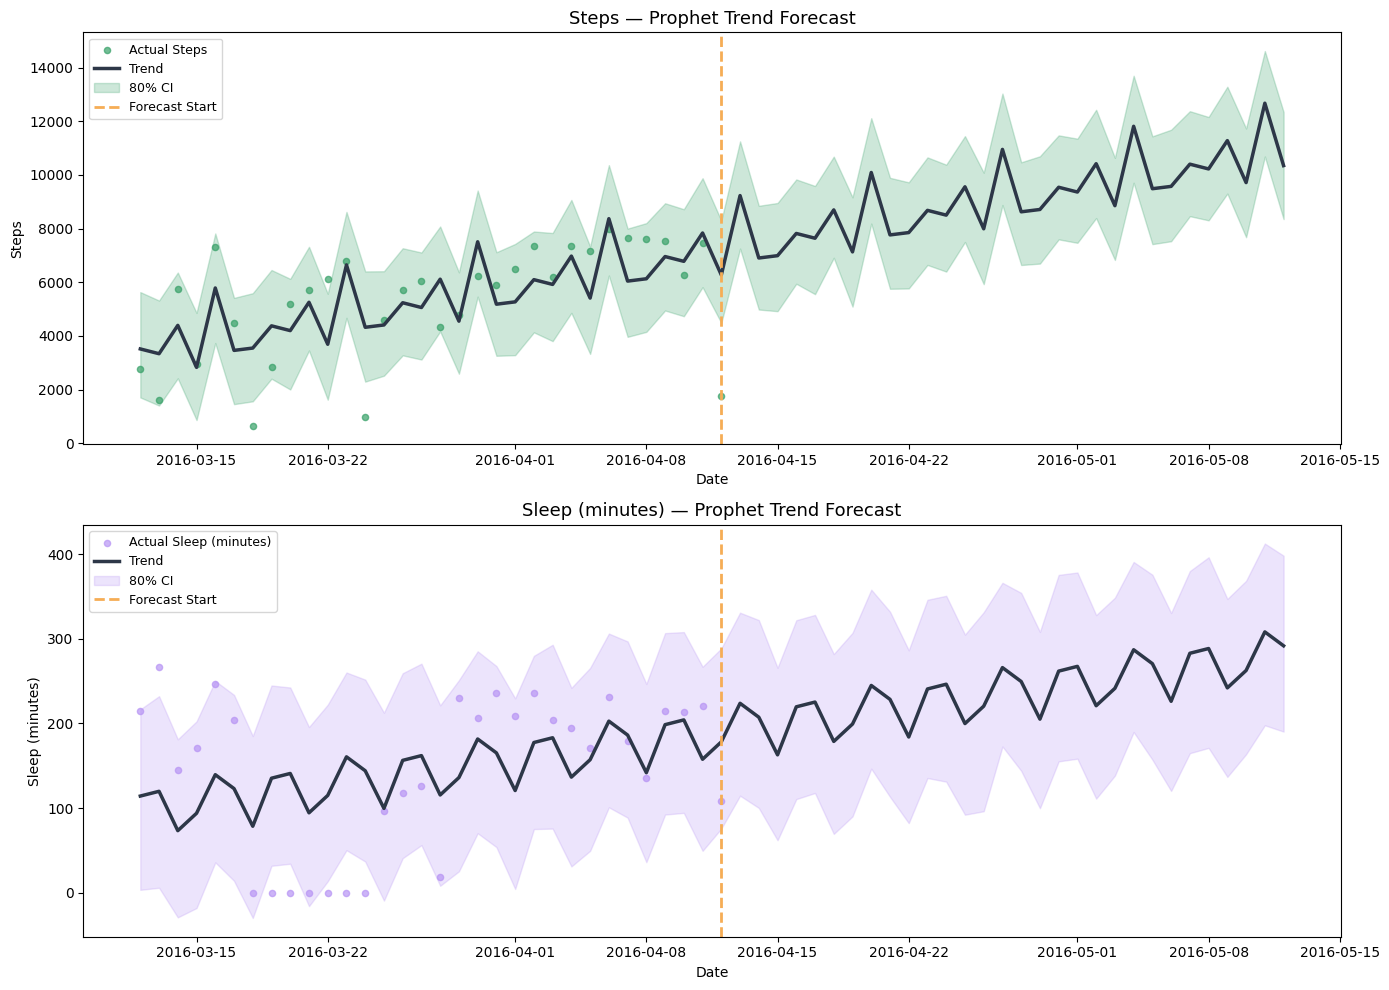

✅ Steps and Sleep Prophet graphs — SCREENSHOT THIS


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

configs = [
    ("TotalSteps",        "ActivityDate", daily,  "#38a169", "Steps"),
    ("TotalSleepMinutes", "Date",         master, "#b794f4", "Sleep (minutes)"),
]

for ax, (metric, date_col, df_src, color, label) in zip(axes, configs):
    daily_agg = (
        df_src.groupby(date_col)[metric]
        .mean()
        .reset_index()
    )
    daily_agg.columns = ["ds", "y"]
    daily_agg["ds"] = pd.to_datetime(daily_agg["ds"], errors="coerce")
    daily_agg = daily_agg.dropna(subset=["ds", "y"]).sort_values("ds")

    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.80,
        changepoint_prior_scale=0.1
    )
    m.fit(daily_agg)
    future   = m.make_future_dataframe(periods=30)
    forecast = m.predict(future)

    ax.scatter(daily_agg["ds"], daily_agg["y"],
               color=color, s=20, alpha=0.7,
               label=f"Actual {label}")
    ax.plot(forecast["ds"], forecast["yhat"],
            color="#2d3748", linewidth=2.5, label="Trend")
    ax.fill_between(forecast["ds"],
                    forecast["yhat_lower"],
                    forecast["yhat_upper"],
                    alpha=0.25, color=color, label="80% CI")
    ax.axvline(daily_agg["ds"].max(),
               color="#f6ad55", linestyle="--",
               linewidth=2, label="Forecast Start")
    ax.set_title(f"{label} — Prophet Trend Forecast", fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel(label)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("✅ Steps and Sleep Prophet graphs — SCREENSHOT THIS")

---
## 🤖 Milestone 2 · Clustering

### Step 18 · Build Clustering Feature Matrix

In [20]:
cluster_cols = [
    "TotalSteps",
    "Calories",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "TotalSleepMinutes"
]

hr_cols = ["AvgHR", "MaxHR", "MinHR", "StdHR"]
for col in hr_cols:
    if col in master.columns:
        cluster_cols.append(col)

# Use daily directly — has all 35 users, drop HR cols if causing drops
cluster_cols_no_hr = [
    "TotalSteps", "Calories", "VeryActiveMinutes",
    "FairlyActiveMinutes", "LightlyActiveMinutes",
    "SedentaryMinutes", "TotalSleepMinutes"
]
cluster_features = (
    master.groupby("Id")[cluster_cols_no_hr]
    .mean()
    .round(3)
)
cluster_features = cluster_features.dropna()
print(f"Users available for clustering: {cluster_features.shape[0]}")

cluster_features = cluster_features.dropna()

print("✅ Clustering feature matrix ready")
print(f"Users    : {cluster_features.shape[0]}")
print(f"Features : {cluster_features.shape[1]}")
print(f"\nFeatures used: {cluster_cols}")
print(f"\nUser feature matrix:")
display(cluster_features)

Users available for clustering: 35
✅ Clustering feature matrix ready
Users    : 35
Features : 7

Features used: ['TotalSteps', 'Calories', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'TotalSleepMinutes', 'AvgHR', 'MaxHR', 'MinHR', 'StdHR']

User feature matrix:


,TotalSteps,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,TotalSleepMinutes
Id,,,,,,,
1503960366,11640.526,1796.211,35.842,15.842,228.211,809.842,276.632
1624580081,4226.263,1352.895,0.737,0.579,121.053,1278.316,0.000
1644430081,9274.800,2916.400,14.800,43.500,227.700,1034.200,0.000
1844505072,3640.583,1615.917,0.750,0.750,158.500,1035.333,160.167
1927972279,2180.833,2254.000,0.000,1.667,111.667,952.917,308.917
2022484408,12174.917,2475.333,40.083,22.500,253.833,1058.917,0.000
2026352035,3392.750,1355.500,0.000,0.000,169.333,659.167,544.750
2320127002,3138.417,1532.083,0.917,1.083,125.917,1249.250,0.000
2347167796,9800.067,2021.333,11.800,23.133,253.533,683.867,400.000


### Step 19 · Scale Features

In [21]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

print("✅ StandardScaler applied")
print(f"Shape      : {X_scaled.shape}")
print(f"Mean (≈0)  : {X_scaled.mean():.6f}")
print(f"Std  (≈1)  : {X_scaled.std():.6f}")

✅ StandardScaler applied
Shape      : (35, 7)
Mean (≈0)  : -0.000000
Std  (≈1)  : 1.000000


### Step 20 · KMeans Elbow Curve (Screenshot This)

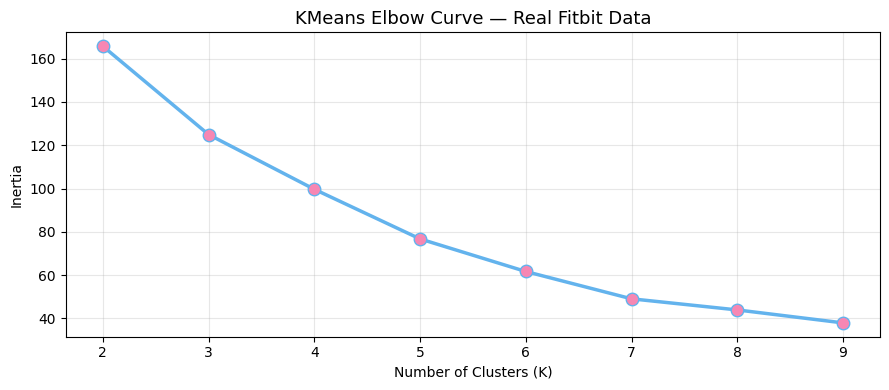

✅ Elbow curve — SCREENSHOT THIS
   Choose K at the point where the curve bends (elbow)


In [22]:
inertias = []
K_range  = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, "o-",
         color="#63b3ed", linewidth=2.5, markersize=9,
         markerfacecolor="#f687b3")
plt.title("KMeans Elbow Curve — Real Fitbit Data", fontsize=13)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Elbow curve — SCREENSHOT THIS")
print("   Choose K at the point where the curve bends (elbow)")

### Step 21 · Fit KMeans

In [23]:
OPTIMAL_K = 3  # ← change this based on elbow curve above

kmeans        = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

cluster_features["KMeans_Cluster"] = kmeans_labels

print(f"✅ KMeans fitted with K={OPTIMAL_K}")
print("\nCluster distribution:")
print(cluster_features["KMeans_Cluster"].value_counts().sort_index())

print("\nCluster profiles — Average values:")
feature_cols = [c for c in cluster_features.columns if c != "KMeans_Cluster"]
profile = cluster_features.groupby("KMeans_Cluster")[feature_cols].mean().round(2)
display(profile)

✅ KMeans fitted with K=3

Cluster distribution:
KMeans_Cluster
0    12
1    15
2     8
Name: count, dtype: int64

Cluster profiles — Average values:


,TotalSteps,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,TotalSleepMinutes
KMeans_Cluster,,,,,,,
0,7666.35,1978.03,13.47,14.96,210.76,757.53,391.26
1,3237.55,1932.11,3.22,8.65,129.43,1194.28,45.28
2,11034.24,2968.05,51.04,24.55,200.57,952.78,130.95


### Step 22 · Fit DBSCAN

In [24]:
EPS         = 2.2
MIN_SAMPLES = 2

dbscan        = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)

cluster_features["DBSCAN_Cluster"] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise    = list(dbscan_labels).count(-1)

print(f"✅ DBSCAN fitted — eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"Clusters found      : {n_clusters}")
print(f"Noise/outlier users : {n_noise} out of {len(dbscan_labels)}")
print(f"Noise percentage    : {n_noise/len(dbscan_labels)*100:.1f}%")
print("\nCluster distribution:")
print(cluster_features["DBSCAN_Cluster"].value_counts().sort_index())

✅ DBSCAN fitted — eps=2.2, min_samples=2
Clusters found      : 3
Noise/outlier users : 1 out of 35
Noise percentage    : 2.9%

Cluster distribution:
DBSCAN_Cluster
-1     1
 0    26
 1     6
 2     2
Name: count, dtype: int64


### Step 23 · PCA Reduction to 2D

In [25]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_ * 100

print(f"✅ PCA complete")
print(f"PC1 variance explained : {var_explained[0]:.1f}%")
print(f"PC2 variance explained : {var_explained[1]:.1f}%")
print(f"Total explained        : {sum(var_explained):.1f}%")

✅ PCA complete
PC1 variance explained : 44.7%
PC2 variance explained : 23.1%
Total explained        : 67.8%


### Step 24 · KMeans PCA Plot (Screenshot This)

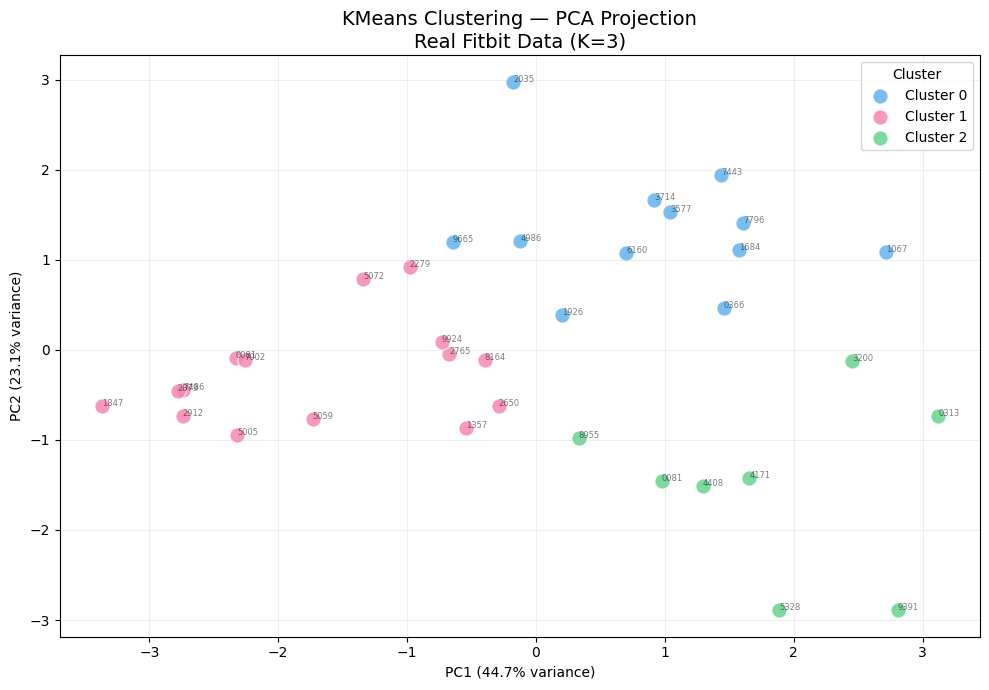

✅ KMeans PCA plot — SCREENSHOT THIS


In [26]:
palette = ["#63b3ed", "#f687b3", "#68d391",
           "#f6ad55", "#b794f4", "#fc8181"]

plt.figure(figsize=(10, 7))

for cluster_id in sorted(set(kmeans_labels)):
    mask = kmeans_labels == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette[cluster_id % len(palette)],
        label=f"Cluster {cluster_id}",
        s=120, alpha=0.85,
        edgecolors="white", linewidths=0.8
    )
    for i, uid in enumerate(cluster_features.index[mask]):
        plt.annotate(str(uid)[-4:],
                     (X_pca[mask][i, 0], X_pca[mask][i, 1]),
                     fontsize=6, alpha=0.5)

plt.title(f"KMeans Clustering — PCA Projection\nReal Fitbit Data (K={OPTIMAL_K})", fontsize=14)
plt.xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
plt.legend(title="Cluster", fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("✅ KMeans PCA plot — SCREENSHOT THIS")

### Step 25 · DBSCAN PCA Plot (Screenshot This)

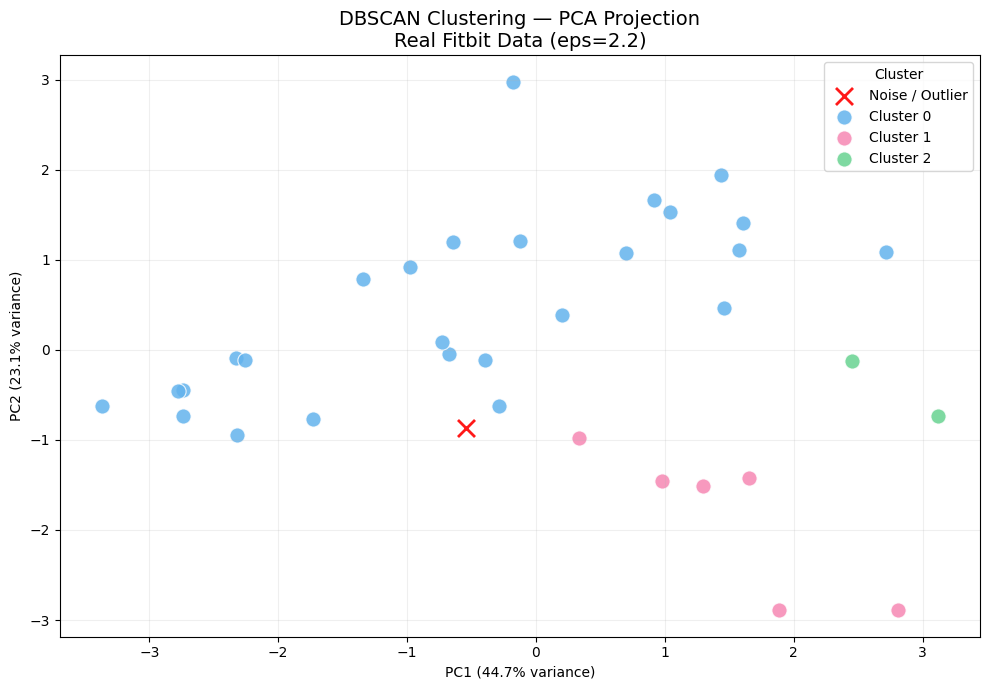

✅ DBSCAN PCA plot — SCREENSHOT THIS


In [27]:
plt.figure(figsize=(10, 7))

for label in sorted(set(dbscan_labels)):
    mask = dbscan_labels == label
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c="red", marker="x", s=150,
                    label="Noise / Outlier",
                    alpha=0.9, linewidths=2)
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette[label % len(palette)],
                    label=f"Cluster {label}",
                    s=120, alpha=0.85,
                    edgecolors="white", linewidths=0.8)

plt.title(f"DBSCAN Clustering — PCA Projection\nReal Fitbit Data (eps={EPS})", fontsize=14)
plt.xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
plt.legend(title="Cluster", fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("✅ DBSCAN PCA plot — SCREENSHOT THIS")

### Step 26 · t-SNE Projection (Screenshot This)

⏳ Running t-SNE... (takes ~30 seconds)


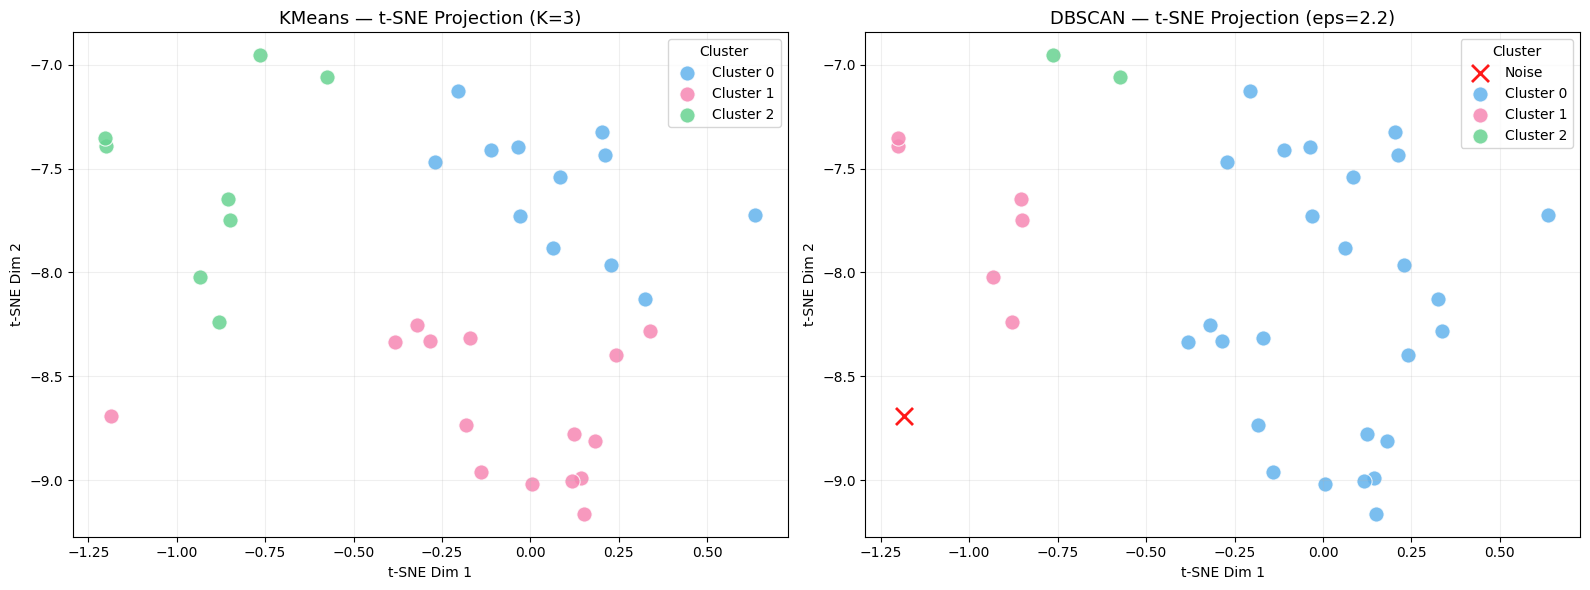

✅ t-SNE projection — SCREENSHOT THIS


In [28]:
print("⏳ Running t-SNE... (takes ~30 seconds)")

tsne   = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(X_scaled) - 1),
    max_iter=1000
)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans t-SNE
for cluster_id in sorted(set(kmeans_labels)):
    mask = kmeans_labels == cluster_id
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=palette[cluster_id % len(palette)],
                    label=f"Cluster {cluster_id}",
                    s=120, alpha=0.85,
                    edgecolors="white", linewidths=0.8)
axes[0].set_title(f"KMeans — t-SNE Projection (K={OPTIMAL_K})", fontsize=13)
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")
axes[0].legend(title="Cluster")
axes[0].grid(alpha=0.2)

# DBSCAN t-SNE
for label in sorted(set(dbscan_labels)):
    mask = dbscan_labels == label
    if label == -1:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c="red", marker="x", s=150,
                        label="Noise", alpha=0.9, linewidths=2)
    else:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c=palette[label % len(palette)],
                        label=f"Cluster {label}",
                        s=120, alpha=0.85,
                        edgecolors="white", linewidths=0.8)
axes[1].set_title(f"DBSCAN — t-SNE Projection (eps={EPS})", fontsize=13)
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")
axes[1].legend(title="Cluster")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()
print("✅ t-SNE projection — SCREENSHOT THIS")

### Step 27 · Cluster Profiling — What Each Cluster Means

📊 KMeans Cluster Profiles — Real Fitbit Users



,TotalSteps,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,TotalSleepMinutes,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,
0,7666.35,1978.03,13.47,14.96,210.76,757.53,391.26,0.00
1,3237.55,1932.11,3.22,8.65,129.43,1194.28,45.28,-0.07
2,11034.24,2968.05,51.04,24.55,200.57,952.78,130.95,1.25


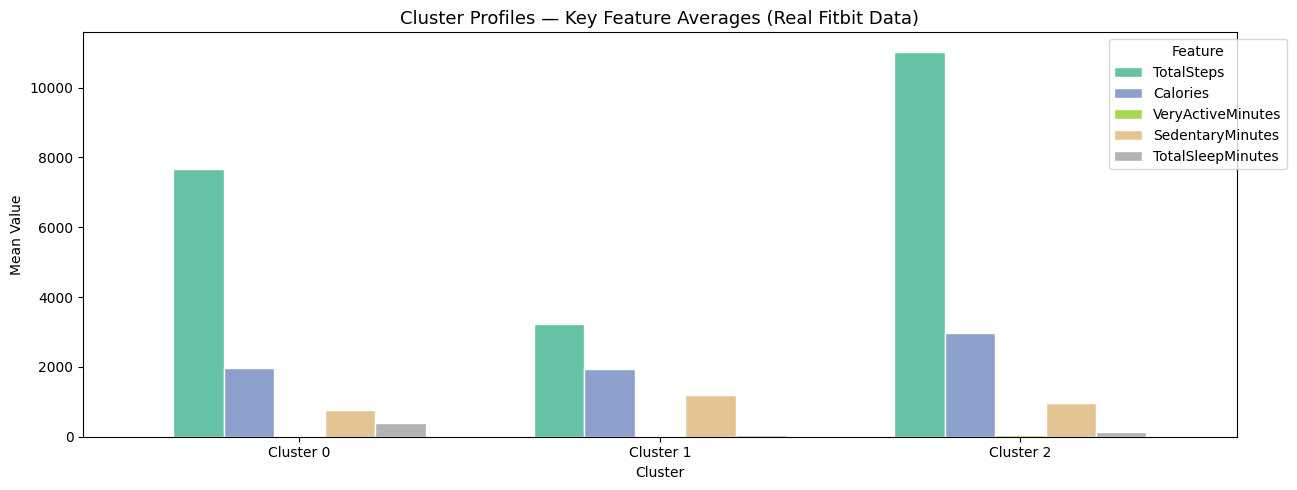


📊 Interpretation:

Cluster 0:
  Avg Steps           : 7,666
  Sedentary Minutes   : 758
  Very Active Minutes : 13
  → Profile: 🚶 MODERATELY ACTIVE users

Cluster 1:
  Avg Steps           : 3,238
  Sedentary Minutes   : 1194
  Very Active Minutes : 3
  → Profile: 🛋️  SEDENTARY users

Cluster 2:
  Avg Steps           : 11,034
  Sedentary Minutes   : 953
  Very Active Minutes : 51
  → Profile: 🏃 HIGHLY ACTIVE users


In [29]:
print("📊 KMeans Cluster Profiles — Real Fitbit Users\n")
feature_cols = [c for c in cluster_features.columns if c != "KMeans_Cluster"]
profile = cluster_features.groupby("KMeans_Cluster")[feature_cols].mean().round(2)
display(profile)

fig, ax = plt.subplots(figsize=(13, 5))
profile[["TotalSteps", "Calories", "VeryActiveMinutes",
         "SedentaryMinutes", "TotalSleepMinutes"]].plot(
    kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.7
)
ax.set_title("Cluster Profiles — Key Feature Averages (Real Fitbit Data)", fontsize=13)
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean Value")
ax.set_xticklabels([f"Cluster {i}" for i in range(OPTIMAL_K)], rotation=0)
ax.legend(bbox_to_anchor=(1.05, 1), title="Feature")
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
for i in range(OPTIMAL_K):
    row    = profile.loc[i]
    steps  = row["TotalSteps"]
    sed    = row["SedentaryMinutes"]
    active = row["VeryActiveMinutes"]
    print(f"\nCluster {i}:")
    print(f"  Avg Steps           : {steps:,.0f}")
    print(f"  Sedentary Minutes   : {sed:.0f}")
    print(f"  Very Active Minutes : {active:.0f}")
    if steps > 10000:
        print(f"  → Profile: 🏃 HIGHLY ACTIVE users")
    elif steps > 5000:
        print(f"  → Profile: 🚶 MODERATELY ACTIVE users")
    else:
        print(f"  → Profile: 🛋️  SEDENTARY users")

---
## ✅ Milestone 2 Summary

In [30]:
print("=" * 55)
print("   MILESTONE 2 SUMMARY — REAL FITBIT DATA")
print("=" * 55)

print(f"\n✅ Dataset : Real Fitbit device data")
print(f"   Users   : {cluster_features.shape[0]}")
print(f"   Days    : 31 (March–April 2016)")

print(f"\n✅ TSFresh features extracted : {features.shape[1]} features")
print(f"   Source  : Real minute-level heart rate data")

print(f"\n✅ Prophet models fitted:")
print(f"   Heart Rate  — 30 day forecast, 80% CI")
print(f"   Steps       — 30 day forecast, 80% CI")
print(f"   Sleep       — 30 day forecast, 80% CI")

print(f"\n✅ KMeans : {OPTIMAL_K} clusters identified")
print(f"   Distribution : {dict(cluster_features['KMeans_Cluster'].value_counts().sort_index())}")

print(f"\n✅ DBSCAN : {n_clusters} clusters, {n_noise} noise/outlier users")
print(f"   Noise % : {n_noise/len(dbscan_labels)*100:.1f}%")

print(f"\n📸 Screenshots to submit for Milestone 2:")
print(f"   1.  Cell 15 — TSFresh feature matrix heatmap")
print(f"   2.  Cell 18 — Prophet HR forecast with confidence interval")
print(f"   3.  Cell 20 — Steps and Sleep Prophet forecasts")
print(f"   4.  Cell 27 — KMeans PCA scatter plot")
print(f"   5.  Cell 28 — DBSCAN PCA scatter plot")
print(f"   6.  Cell 29 — t-SNE projection (both models)")
print(f"   7.  Cell 30 — Cluster profiles bar chart")
print("=" * 55)

   MILESTONE 2 SUMMARY — REAL FITBIT DATA

✅ Dataset : Real Fitbit device data
   Users   : 35
   Days    : 31 (March–April 2016)

✅ TSFresh features extracted : 10 features
   Source  : Real minute-level heart rate data

✅ Prophet models fitted:
   Heart Rate  — 30 day forecast, 80% CI
   Steps       — 30 day forecast, 80% CI
   Sleep       — 30 day forecast, 80% CI

✅ KMeans : 3 clusters identified
   Distribution : {0: np.int64(12), 1: np.int64(15), 2: np.int64(8)}

✅ DBSCAN : 3 clusters, 1 noise/outlier users
   Noise % : 2.9%

📸 Screenshots to submit for Milestone 2:
   1.  Cell 15 — TSFresh feature matrix heatmap
   2.  Cell 18 — Prophet HR forecast with confidence interval
   3.  Cell 20 — Steps and Sleep Prophet forecasts
   4.  Cell 27 — KMeans PCA scatter plot
   5.  Cell 28 — DBSCAN PCA scatter plot
   6.  Cell 29 — t-SNE projection (both models)
   7.  Cell 30 — Cluster profiles bar chart
